In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── CELL 1: Run this FIRST before anything else ──
import os
import random as rn
import numpy as np

seed = 101  # your seed

os.environ['PYTHONHASHSEED']       = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

np.random.seed(seed)
rn.seed(seed)

In [3]:
import os
import cv2
import shutil
import requests
import numpy as np
import pandas as pd
import random as rn
import tensorflow as tf
import matplotlib.pyplot as plt
from zipfile import ZipFile
from tensorflow import keras
from keras import Model
from keras import applications
from keras import regularizers
from keras import backend as K
from keras.layers import Dense,Dropout
from sklearn import metrics
from sklearn import preprocessing
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Read Meta

In [4]:
metadata_path="/content/drive/MyDrive/Research/ipynb_code/Skin-cancer-main/data/metadata.csv"
meta = pd.read_csv(metadata_path)
meta=meta.drop(['patient_id','lesion_id'],axis=1)

In [13]:
meta['smoke']=meta['smoke'].map({True: 2, False: 1})
meta['smoke']=meta['smoke'].fillna(0)

meta['drink']=meta['drink'].map({True: 2, False: 1})
meta['drink']=meta['drink'].fillna(0)

meta['pesticide']=meta['pesticide'].map({True: 2, False: 1})
meta['pesticide']=meta['pesticide'].fillna(0)

meta['gender']=meta['gender'].map({'FEMALE': 2, 'MALE': 1})
meta['gender']=meta['gender'].fillna(0)

meta['skin_cancer_history']=meta['skin_cancer_history'].map({True: 2, False: 1})
meta['skin_cancer_history']=meta['skin_cancer_history'].fillna(0)

meta['cancer_history']=meta['cancer_history'].map({True: 2, False: 1})
meta['cancer_history']=meta['cancer_history'].fillna(0)

meta['has_piped_water']=meta['has_piped_water'].map({True: 2, False: 1})
meta['has_piped_water']=meta['has_piped_water'].fillna(0)

meta['has_sewage_system']=meta['has_sewage_system'].map({True: 2, False: 1})
meta['has_sewage_system']=meta['has_sewage_system'].fillna(0)

meta['biopsed']=meta['biopsed'].map({True: 2, False: 1})
meta['biopsed']=meta['biopsed'].fillna(0)

# digits
meta['fitspatrick']=meta['fitspatrick'].fillna(-1)
meta['diameter_1']=meta['diameter_1'].fillna(-1)
meta['diameter_2']=meta['diameter_2'].fillna(-1)

meta['itch']=meta['itch'].map({'True': 2, 'False': 1,'UNK':0}).fillna(0)
meta['grew']=meta['grew'].map({'True': 2, 'False': 1,'UNK':0}).fillna(0)
meta['hurt']=meta['hurt'].map({'True': 2, 'False': 1,'UNK':0}).fillna(0)
meta['changed']=meta['changed'].map({'True': 2, 'False': 1,'UNK':0}).fillna(0)
meta['bleed']=meta['bleed'].map({'True': 2, 'False': 1,'UNK':0}).fillna(0)
meta['elevation']=meta['elevation'].map({'True': 2, 'False': 1,'UNK':0}).fillna(0)

meta['background_father']=meta['background_father'].fillna('None')
meta['background_mother']=meta['background_mother'].fillna('None')

In [15]:
for i in meta.columns:
  if meta[i].dtypes=='O':
    if i!="img_id":
      ls=meta[i].values.tolist()
      le = preprocessing.LabelEncoder()
      meta[i] = le.fit_transform(meta[i])

In [ ]:
meta

,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,0.0,0.0,8,6,8,0.0,0.0,0.0,0.0,0.0,...,-1.0,3,1,1,1,1,1,1,PAT_1516_1765_530.png,1
1,1.0,1.0,10,8,55,1.0,2.0,2.0,2.0,2.0,...,5.0,1,2,2,1,2,2,2,PAT_46_881_939.png,2
2,0.0,0.0,8,6,77,0.0,0.0,0.0,0.0,0.0,...,-1.0,0,2,1,1,1,1,1,PAT_1545_1867_547.png,1
3,0.0,0.0,8,6,75,0.0,0.0,0.0,0.0,0.0,...,-1.0,0,2,1,1,1,1,1,PAT_1989_4061_934.png,1
4,1.0,2.0,10,8,79,1.0,1.0,2.0,1.0,1.0,...,5.0,1,2,2,1,1,2,2,PAT_684_1302_588.png,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2293,0.0,0.0,8,6,73,0.0,0.0,0.0,0.0,0.0,...,-1.0,0,2,1,1,1,1,1,PAT_1708_3156_175.png,1
2294,1.0,1.0,10,8,55,1.0,2.0,2.0,2.0,2.0,...,12.0,1,2,2,1,2,1,1,PAT_46_880_140.png,2
2295,0.0,0.0,8,6,74,0.0,0.0,0.0,0.0,0.0,...,-1.0,5,1,1,1,1,1,1,PAT_1343_1217_404.png,1
2296,1.0,1.0,10,8,58,2.0,2.0,2.0,2.0,1.0,...,4.0,1,2,1,1,1,1,2,PAT_326_690_823.png,2


#Pre-processing

In [16]:
num_cores=1
os.environ['PYTHONHASHSEED'] = '0'
np.random.seed(seed)
rn.seed(seed)
tf.random.set_seed(seed)

# The following lines are removed because they cause a RuntimeError if TensorFlow is already initialized.
# tf.config.threading.set_intra_op_parallelism_threads(num_cores)
# tf.config.threading.set_inter_op_parallelism_threads(num_cores)

#getting features from images
with tf.device('/cpu:0'):
  model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

In [17]:
# Temporarily reload original img_id strings from metadata to prevent TypeError
# This assumes 'metadata_path' is defined and points to the original metadata.csv
original_img_id_series = pd.read_csv(metadata_path)['img_id']

for indx, i in enumerate(original_img_id_series):
    path = os.path.join("/content/drive/MyDrive/Research/ipynb_code/Skin-cancer-main/data/all_images", i)
    # Image target size changed from (380,380) to (224,224) to match the MobileNetV2 input shape
    image = tf.keras.utils.load_img(path, target_size=(224, 224))
    input_arr = tf.keras.preprocessing.image.img_to_array(image)
    input_arr = cv2.cvtColor(input_arr, cv2.COLOR_BGR2RGB)
    input_arr = np.array([input_arr])
    input_arr = input_arr / 255
    with tf.device('/cpu:0'): # Ensure prediction also happens on CPU
      features = model.predict(input_arr)
    nx, ny, _ = features[0].shape
    d2_train_dataset = features[0].reshape(nx * ny * _)
    meta.at[indx, 'img_id'] = d2_train_dataset # Use .at for scalar assignment to store the numpy array as a single object in the cell

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━

#Split Data

In [18]:
train,test0=train_test_split(meta,test_size=0.2,random_state=seed)
valid,test=train_test_split(test0,test_size=0.5,random_state=seed)

In [19]:
imgF=[]
for indx in train.index:
  imgF.append(train['img_id'][indx])

imgF_tst=[]
for indx in test.index:
  imgF_tst.append(test['img_id'][indx])

imgF_valid=[]
for indx in valid.index:
  imgF_valid.append(valid['img_id'][indx])

In [20]:
target=train['diagnostic']
x=train.drop(['diagnostic','img_id','background_father'],axis=1)

target_test=test['diagnostic']
x_test=test.drop(['diagnostic','img_id','background_father'],axis=1)

target_valid=valid['diagnostic']
x_valid=valid.drop(['diagnostic','img_id','background_father'],axis=1)

In [21]:
meta_clf = RandomForestClassifier(random_state=seed)
img_clf = LogisticRegression(random_state=seed, max_iter=1000)
img_clf.fit(imgF, target)
meta_clf.fit(x, target)

RandomForestClassifier(random_state=101)

In [22]:
def multiclass_accuracy_score(y_test, y_pred, average="macro"):
        lb = LabelBinarizer()
        lb.fit(y_test)
        y_test = lb.transform(y_test)
        y_pred = lb.transform(y_pred)

        return  metrics.accuracy_score(y_test,y_pred)
        # return metrics.roc_auc_score(y_test, y_pred, average=average)

#Meta + Image in one Model

In [23]:
predicted_img_labels_tst = img_clf.predict_proba(imgF_tst)
predicted_meta_labels_tst = meta_clf.predict_proba(x_test)

predicted_img_labels_valid = img_clf.predict_proba(imgF_valid)
predicted_meta_labels_valid = meta_clf.predict_proba(x_valid)

In [24]:
pre_img=[]
for i in predicted_img_labels_tst:
  pre_img.append(np.argmax(i))

pre_meta=[]
for i in predicted_meta_labels_tst:
  pre_meta.append(np.argmax(i))

In [ ]:
print('img',multiclass_accuracy_score(pre_img,target_test)*100)
print('meta',multiclass_accuracy_score(pre_meta,target_test)*100)

img 65.21739130434783
meta 73.91304347826086


In [26]:
all_x=[]
all_im=[]
all_y=[]
for i in range(len(predicted_meta_labels_valid)):
  all_x.append(predicted_meta_labels_valid[i])
  all_im.append(predicted_img_labels_valid[i])
  all_y.append(target_valid.iloc[i])

  all_x.append(predicted_meta_labels_tst[i])
  all_im.append(predicted_img_labels_tst[i])
  all_y.append(target_test.iloc[i])

In [27]:
dict = {'meta': all_x, 'image': all_im, 'label': all_y}
df = pd.DataFrame(dict)

In [ ]:
df

,meta,image,label
0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.004061240624716062, 0.07063830470674712, 9....",0
1,"[0.21, 0.0, 0.0, 0.0, 0.0, 0.79]","[2.391423689129827e-06, 0.9885252911002861, 1....",5
2,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.9999804516489698, 1.9521513650302876e-05, 4...",0
3,"[0.93, 0.0, 0.0, 0.01, 0.0, 0.06]","[0.9993386408277762, 3.2072214363774035e-08, 1...",0
4,"[0.64, 0.19, 0.0, 0.0, 0.17, 0.0]","[0.23278781222726935, 0.605859145025308, 6.520...",0
...,...,...,...
455,"[0.02, 0.8, 0.0, 0.01, 0.16, 0.01]","[0.29717014778899953, 0.7028298324514438, 7.53...",1
456,"[0.09, 0.73, 0.0, 0.0, 0.18, 0.0]","[1.1531481553860057e-06, 0.01078537737781342, ...",1
457,"[0.04, 0.88, 0.0, 0.01, 0.07, 0.0]","[1.3795596119816178e-06, 0.999860993476166, 0....",1
458,"[0.05, 0.24, 0.2, 0.07, 0.42, 0.02]","[2.3067624543820716e-11, 0.9999999998649127, 1...",3


In [28]:
train,test0=train_test_split(df,test_size=0.2,random_state=seed)
test,valid=train_test_split(test0,test_size=0.5,random_state=seed)

In [29]:
x_train=train.drop(['label'],axis=1)
y_train=train['label']

x_test=test.drop(['label'],axis=1)
y_test=test['label']

x_valid=valid.drop(['label'],axis=1)
y_valid=valid['label']

In [46]:
num_cores=1
os.environ['PYTHONHASHSEED'] = '0'
np.random.seed(seed)
rn.seed(seed)
tf.random.set_seed(seed)

tf.keras.backend.clear_session()

# Removed: tf.compat.v1.ConfigProto and K.set_session are deprecated/removed in TF2.x
# session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=num_cores,
#                               inter_op_parallelism_threads=num_cores,
#                               allow_soft_placement=True,
#                               device_count = {'CPU' : 1, 'GPU' : 0})
# sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
# K.set_session(sess)

with tf.device('/cpu:0'):
  model_inputs=[]
  for i in range(2):
    model_inputs.append(keras.Input(shape=(6,)))

  combinedInput = tf.keras.layers.concatenate(model_inputs)
  # 390
  x = Dense(1024,activation="relu",
            kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4),
            )(combinedInput)

  x=Dropout(.9)(x)
  predictions = Dense(6,activation="softmax")(x)

  model = Model(inputs=model_inputs,outputs=predictions)

  opt= keras.optimizers.Adam(learning_rate=0.0001,epsilon=0.01)
  model.compile(optimizer=opt,loss="sparse_categorical_crossentropy",metrics=['accuracy'])

  # The following two model.fit calls are commented out to avoid redundant training
  # and the NameError, as the last model.fit call handles the primary training.
  # test
  # model.fit([predicted_img_labels_tst,predicted_meta_labels_tst],target_test ,epochs=200,validation_split=.2,batch_size=16)#validation_data=(validList,validDic['diagnostic'])

  # train
  # model.fit([predicted_img_labels,predicted_meta_labels],target ,epochs=100,validation_split=.1,batch_size=16)#validation_data=(validList,validDic['diagnostic'])

  # valid
  hist = model.fit([np.array(x_train['meta'].tolist()),np.array(x_train['image'].tolist())],y_train ,epochs=200,validation_data=([np.array(x_test['meta'].tolist()),np.array(x_test['image'].tolist())],y_test),batch_size=16)#validation_data=(validList,validDic['diagnostic'])

print("evaluate")

# valid
# model_loss,modelAccuracy = model.evaluate([predicted_img_labels_valid,predicted_meta_labels_valid],target_valid)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1549 - loss: 1.8068 - val_accuracy: 0.0870 - val_loss: 1.7780
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1957 - loss: 1.7803 - val_accuracy: 0.2609 - val_loss: 1.7673
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1957 - loss: 1.7783 - val_accuracy: 0.4348 - val_loss: 1.7550
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2310 - loss: 1.7622 - val_accuracy: 0.5217 - val_loss: 1.7417
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2853 - loss: 1.7376 - val_accuracy: 0.5217 - val_loss: 1.7276
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3152 - loss: 1.7296 - val_accuracy: 0.5435 - val_loss: 1.7130
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3750 - loss: 1.7095 - val_accuracy: 0.5435 - val_loss: 1.6984
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3886 - loss: 1.6887 - val_accuracy: 0.5435 - v

In [47]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [48]:
# test
with tf.device('/cpu:0'):
  model_loss,modelAccuracy = model.evaluate([np.array(x_valid['meta'].tolist()),np.array(x_valid['image'].tolist())],y_valid)
print("Model Accuracy "+str(modelAccuracy))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8478 - loss: 0.5178
Model Accuracy 0.8478260636329651


#Visualize

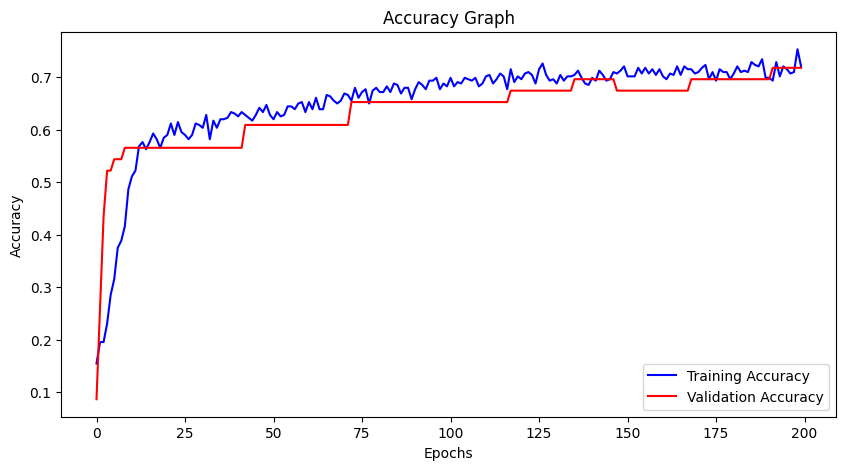

In [37]:
plt.figure(figsize=(10,5))
plt.plot(hist.history['accuracy'],color='b',label='Training Accuracy')
plt.plot(hist.history['val_accuracy'],color='r',label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Graph")
plt.legend(loc='lower right')

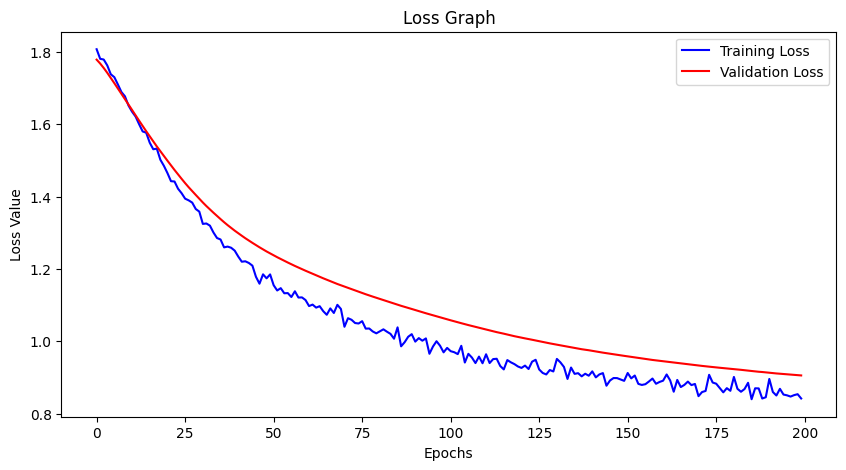

In [38]:
plt.figure(figsize=(10,5))
plt.plot(hist.history['loss'],color='b',label='Training Loss')
plt.plot(hist.history['val_loss'],color='r',label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.title("Loss Graph")
plt.legend(loc='upper right')

In [39]:
predictions = model.predict([np.array(x_valid['meta'].tolist()),np.array(x_valid['image'].tolist())], verbose=0)

In [40]:
from sklearn.metrics import  precision_score, recall_score, accuracy_score,classification_report,roc_auc_score,roc_curve,auc
from tensorflow.keras.utils import to_categorical

#geting predictions on test dataset
y_pred = np.argmax(predictions, axis=1)
targetnames = ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']

#getting the true labels per image
y_true = y_valid

# Creating classification report
report = classification_report(y_true, y_pred)

print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        17
           1       0.89      1.00      0.94        16
           3       1.00      0.67      0.80         9
           4       1.00      0.33      0.50         3
           5       0.25      1.00      0.40         1

    accuracy                           0.85        46
   macro avg       0.80      0.78      0.70        46
weighted avg       0.90      0.85      0.85        46



Text(0.5, 1.0, 'Confusion Matrix')

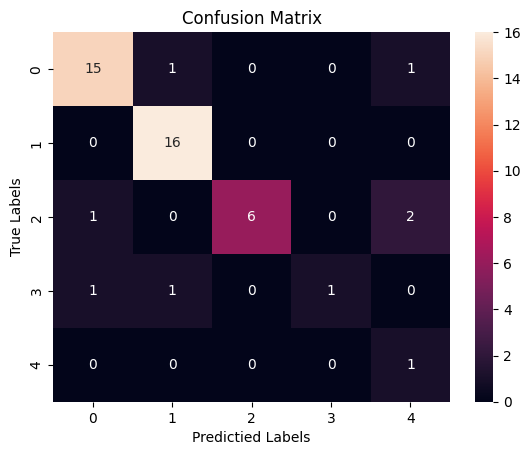

In [41]:
import seaborn as sn
import pandas as pd
from sklearn.metrics import confusion_matrix
cmatrix = confusion_matrix(y_true, y_pred)
ax = plt.subplot()
sn.heatmap(cmatrix,annot=True,fmt='g',ax=ax)
ax.set_xlabel('Predictied Labels');ax.set_ylabel('True Labels');
ax.set_title('Confusion Matrix')

In [42]:
y_valid

,label
24,3
237,1
69,0
156,0
436,1
422,0
312,1
274,0
323,3
240,1


In [43]:
y_test

,label
100,0
412,0
387,0
269,3
395,4
383,0
419,0
325,1
139,1
437,1
